# Práctica 01: análisis y pronóstico de series temporales

Aplicación de Box–Jenkins con una serie temporal seleccionada desde Kaggle, Yahoo Finance o un CSV local. La secuencia es: graficar, probar estacionariedad, diferenciar, identificar con FAC/FACP, estimar, revisar residuos y pronosticar.


## 1. Librerías

Si se utiliza otro entorno, instalar primero: `%pip install yfinance pandas numpy matplotlib statsmodels`.

In [1]:
import warnings
import kagglehub
from kagglehub import KaggleDatasetAdapter

import pandas as pd
import yfinance as yf
import numpy as np
import matplotlib.pyplot as plt

from IPython.display import display
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.graphics.gofplots import qqplot
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch
from statsmodels.stats.stattools import jarque_bera
from statsmodels.tools.sm_exceptions import InterpolationWarning

plt.rcParams['figure.figsize'] = (10, 4)
alpha = 0.05

## 2. Llamado al dataset

Selecciona una fuente en la celda siguiente. El resto del notebook usa automáticamente la variable `serie`, su nombre y su frecuencia.


In [2]:
# Elige la fuente: 'kaggle', 'yahoo' o 'csv'
fuente = 'kaggle'
frecuencia = 'MS'  # 'MS' mensual; usa 'D' para datos diarios

if fuente == 'kaggle':
    # Dataset Electric_Production.csv usado en clase
    file_path = 'Electric_Production.csv'
    data = kagglehub.load_dataset(
        KaggleDatasetAdapter.PANDAS,
        'shenba/time-series-datasets',
        file_path,
    )
    data['DATE'] = pd.to_datetime(data['DATE'])
    data = data.sort_values('DATE').set_index('DATE')
    serie = data['IPG2211A2N'].astype(float).dropna()
    nombre_serie = 'Producción eléctrica (Kaggle)'

elif fuente == 'csv':
    # CSV local: cambia ruta_csv. Debe tener una fecha y una columna numérica.
    ruta_csv = 'mi_dataset.csv'
    data = pd.read_csv(ruta_csv)
    columna_fecha = 'DATE'       # cambia si tu CSV usa 'Fecha' o 'Date'
    columna_valor = 'IPG2211A2N' # cambia por la variable que deseas analizar
    data[columna_fecha] = pd.to_datetime(data[columna_fecha])
    data = data.sort_values(columna_fecha).set_index(columna_fecha)
    serie = pd.to_numeric(data[columna_valor], errors='coerce').dropna()
    nombre_serie = columna_valor

elif fuente == 'yahoo':
    # Yahoo Finance: ejemplo con una empresa del sector eléctrico
    simbolo = 'NEE'
    data = yf.Ticker(simbolo).history(
        start='2000-01-01', end='2026-01-01', interval='1mo',
        auto_adjust=False, actions=False
    )
    if data.empty:
        raise ValueError('Yahoo no devolvió datos. Revisa el ticker o la conexión.')
    data.index = pd.to_datetime(data.index, utc=True).tz_convert(None)
    data = data.sort_index()
    serie = data['Close'].astype(float).dropna()
    nombre_serie = f'{simbolo} (Close mensual)'
else:
    raise ValueError("fuente debe ser 'kaggle', 'csv' o 'yahoo'")

if frecuencia == 'MS':
    serie.index = pd.DatetimeIndex(serie.index).to_period('M').to_timestamp()
    serie = serie[~serie.index.duplicated(keep='first')].asfreq('MS')
elif frecuencia == 'D':
    serie.index = pd.DatetimeIndex(serie.index).floor('D')
    serie = serie[~serie.index.duplicated(keep='first')].asfreq('D')
else:
    raise ValueError("frecuencia debe ser 'MS' o 'D'")
periodo_txt = {'MS': 'mensual', 'D': 'diario'}[frecuencia]
serie = serie.dropna()
if len(serie) < 80:
    raise ValueError('Se necesitan al menos 80 observaciones.')
print(f'{nombre_serie}: {len(serie)} observaciones ({frecuencia})')
print(f'Desde {serie.index.min().date()} hasta {serie.index.max().date()}')

/tmp/ipykernel_1917930/1898096558.py:8: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  data = kagglehub.load_dataset(


Producción eléctrica (Kaggle): 397 observaciones (MS)
Desde 1985-01-01 hasta 2018-01-01


## 3. Dataset y preparación

In [3]:
print('Dimensiones:', data.shape)
print('Periodo:', data.index.min().date(), 'a', data.index.max().date())
display(data.head())
display(data.tail())
data.info()

Dimensiones: (397, 1)
Periodo: 1985-01-01 a 2018-01-01


,IPG2211A2N
DATE,
1985-01-01,72.5052
1985-02-01,70.6720
1985-03-01,62.4502
1985-04-01,57.4714
1985-05-01,55.3151


,IPG2211A2N
DATE,
2017-09-01,98.6154
2017-10-01,93.6137
2017-11-01,97.3359
2017-12-01,114.7212
2018-01-01,129.4048


<class 'pandas.DataFrame'>
DatetimeIndex: 397 entries, 1985-01-01 to 2018-01-01
Data columns (total 1 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   IPG2211A2N  397 non-null    float64
dtypes: float64(1)
memory usage: 6.2 KB


In [4]:
display(data.describe().T)
display(data.isna().sum().rename('Nulos').to_frame())
print('Fechas duplicadas:', data.index.duplicated().sum())

,count,mean,std,min,25%,50%,75%,max
IPG2211A2N,397.0,88.847218,15.387834,55.3151,77.1052,89.7795,100.5244,129.4048


,Nulos
IPG2211A2N,0


Fechas duplicadas: 0


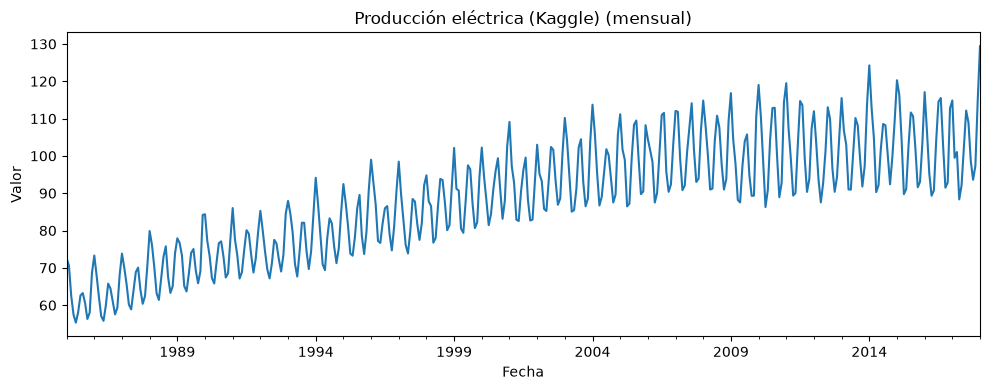

In [5]:
data = data.loc[~data.index.duplicated(keep='first')].copy()
serie = serie.astype(float).dropna().asfreq(frecuencia)
if (serie <= 0).any(): raise ValueError('Hay valores no positivos.')
serie.plot(title=f'{nombre_serie} ({periodo_txt})', ylabel='Valor', xlabel='Fecha')
plt.tight_layout(); plt.show()

## 4. Fase 1: identificación y estacionariedad

### 4.1. División temporal

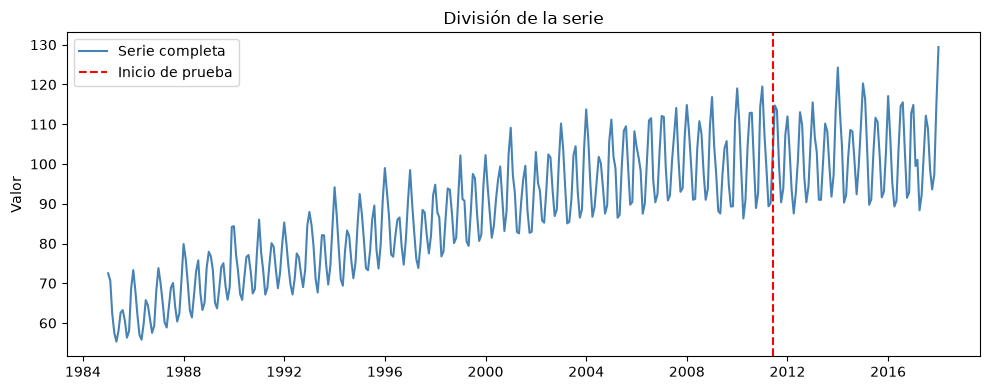

In [6]:
corte = int(len(serie) * 0.8)
train = serie.iloc[:corte]
test = serie.iloc[corte:]

plt.plot(serie, color='steelblue', label='Serie completa')
plt.axvline(test.index[0], color='red', linestyle='--', label='Inicio de prueba')
plt.title('División de la serie')
plt.ylabel('Valor')
plt.legend()
plt.tight_layout()
plt.show()

### 4.1. Prueba de estacionariedad

ADF: H₀ = la serie no es estacionaria; Hₐ = la serie es estacionaria. Si p-valor < 0,05 se rechaza H₀.


In [7]:
def prueba_adf(x, nombre):
    r = adfuller(x.dropna(), autolag='AIC', result_object=False)
    print(f'{nombre}: ADF={r[0]:.4f}; p-valor={r[1]:.4f};', 'estacionaria' if r[1] < alpha else 'no estacionaria')
    return r[1]
corte = int(len(serie) * 0.8)
train, test = serie.iloc[:corte], serie.iloc[corte:]
p0 = prueba_adf(train, 'Original')

Original: ADF=-1.7387; p-valor=0.4113; no estacionaria


### 4.2. Diferenciación

Se revisan d=0, d=1 y d=2. Se usa el menor orden que pase ADF.


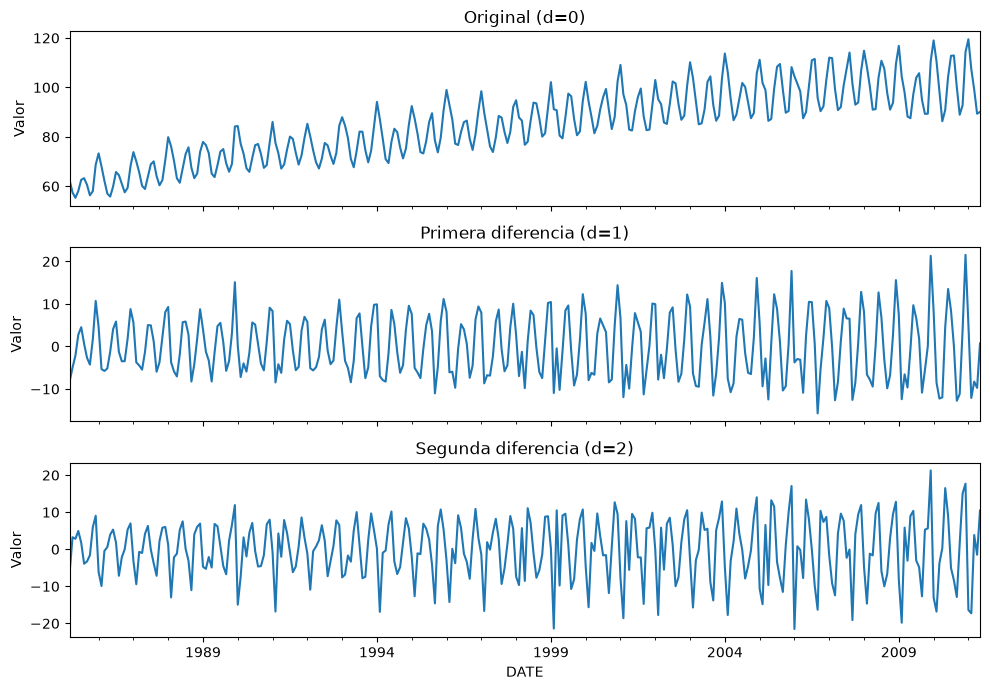

In [8]:
train_diff = train.diff().dropna()
train_diff2 = train_diff.diff().dropna()
series = [train, train_diff, train_diff2]
nombres = ['Original (d=0)', 'Primera diferencia (d=1)', 'Segunda diferencia (d=2)']

fig, axes = plt.subplots(3, 1, figsize=(10, 7), sharex=True)
for x, nombre, ax in zip(series, nombres, axes):
    x.plot(ax=ax, title=nombre)
    ax.set_ylabel('Valor')
plt.tight_layout()
plt.show()

In [9]:
p1 = prueba_adf(train_diff, 'Primera diferencia')
p2 = prueba_adf(train_diff2, 'Segunda diferencia')
if p0 < alpha: d = 0
elif p1 < alpha: d = 1
elif p2 < alpha: d = 2
else: raise ValueError('No se logró estacionariedad con d=0, 1 o 2.')
serie_estacionaria = [train, train_diff, train_diff2][d]
print(f'Orden elegido: d={d}')
serie_estacionaria = [train, train_diff, train_diff2][d]


Primera diferencia: ADF=-6.3530; p-valor=0.0000; estacionaria
Segunda diferencia: ADF=-10.2643; p-valor=0.0000; estacionaria
Orden elegido: d=1


### 4.3. FAC y FACP para identificar p y q

| Modelo sobre la serie estacionaria | FAC | FACP |
|---|---|---|
| AR(p) | Decae gradualmente | Corte después de p |
| MA(q) | Corte después de q | Decae gradualmente |
| ARMA(p,q) | Decae gradualmente | Decae gradualmente |

Estos patrones son orientativos. Se comparan órdenes pequeños con AIC y BIC para apoyar la elección.


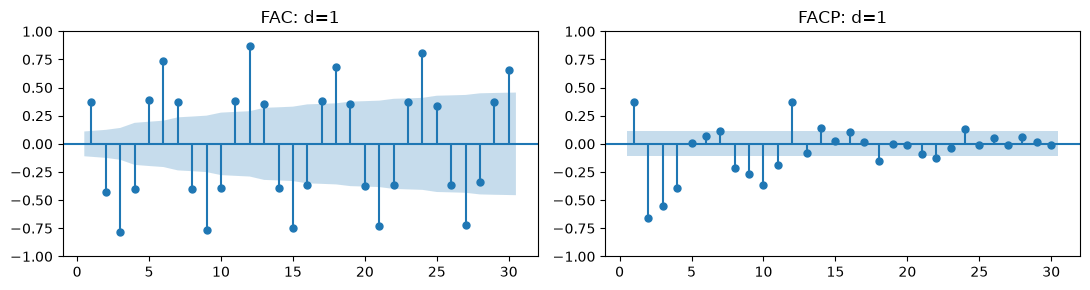

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3))
plot_acf(serie_estacionaria, lags=50, zero=False, ax=axes[0], title=f'FAC: d={d}')
plot_pacf(serie_estacionaria, lags=50, zero=False, method='ywm', ax=axes[1],
          title=f'FACP: d={d}')
plt.tight_layout()
plt.show()

## 5. Fase 2: estimación y comparación de modelos

Con `d=0`, ARIMA(p,0,0) es AR, ARIMA(0,0,q) es MA y ARIMA(p,0,q) es ARMA. Con `d>0`, el modelo de la serie original es **ARIMA(p,d,q)**, aunque las diferencias se modelen con AR, MA o ARMA.

Se prueban `p` y `q` entre 0 y 3. Se incluye ARIMA(0,1,0), un paseo aleatorio sin deriva, cuando `d=1`. Se ajusta **train original**: ARIMA realiza las diferencias internamente y devuelve pronósticos en la escala original de la serie. Se usa constante si `d=0` y sin tendencia determinista si `d>0`.

In [11]:
modelos, resultados = {}, []
trend = 'c' if d == 0 else 'n'
for p in range(3):
    for q in range(3):
        orden = (p, d, q)
        try:
            with warnings.catch_warnings():
                warnings.simplefilter('ignore')
                ajuste = ARIMA(train, order=orden, trend=trend, freq=frecuencia).fit(method_kwargs={'maxiter': 100})
            if np.isfinite(ajuste.aic):
                modelos[orden] = ajuste
                lb = acorr_ljungbox(ajuste.resid.dropna(), lags=[10], return_df=True)
                resultados.append({'Orden': orden, 'AIC': ajuste.aic, 'BIC': ajuste.bic,
                                   'p-Ljung-Box': lb['lb_pvalue'].iloc[0]})
        except (ValueError, np.linalg.LinAlgError):
            pass
if not resultados:
    raise ValueError('No se pudo ajustar ningún modelo.')
comparacion = pd.DataFrame(resultados).sort_values('AIC').reset_index(drop=True)
display(comparacion)
# Se prioriza el modelo de menor AIC entre los que dejan residuos sin autocorrelación.
aceptables = comparacion[comparacion['p-Ljung-Box'] >= alpha]
seleccion = aceptables.iloc[0] if not aceptables.empty else comparacion.iloc[0]
orden_elegido = tuple(seleccion['Orden'])
modelo = modelos[orden_elegido]
criterio = 'AIC y Ljung–Box' if not aceptables.empty else 'AIC (ningún modelo pasó Ljung–Box)'
print(f'Modelo elegido por {criterio}: ARIMA{orden_elegido}')
nombre = f'ARIMA{orden_elegido}'


,Orden,AIC,BIC,p-Ljung-Box
0,"(2, 1, 2)",1649.030288,1667.808999,2.535658e-01
1,"(2, 1, 1)",1763.321188,1778.344157,1.079340e-01
2,"(2, 1, 0)",1924.475746,1935.742972,4.518503e-07
3,"(1, 1, 2)",1955.011227,1970.034196,7.922099e-37
4,"(0, 1, 2)",1981.514822,1992.782048,5.784232e-49
5,"(0, 1, 1)",2049.667812,2057.179297,6.589856e-42
6,"(1, 1, 1)",2051.360556,2062.627782,2.164595e-40
7,"(1, 1, 0)",2105.600250,2113.111734,1.230137e-78
8,"(0, 1, 0)",2150.439230,2154.194972,2.756721e-113


Modelo elegido por AIC y Ljung–Box: ARIMA(2, 1, 2)


## 6. Fase 3: diagnóstico de residuos

### 6.1. Selección con AIC y Ljung–Box

Un AIC menor indica un mejor equilibrio entre ajuste y complejidad dentro de esta comparación. Siguiendo Box–Jenkins, se revisan los modelos en ese orden y se elige el primero sin autocorrelación residual detectada a 10 y 20 rezagos.

Ljung–Box: H₀ = no hay autocorrelación hasta el rezago evaluado. Se descartan los residuos iniciales de inicialización y se descuentan `p+q` grados de libertad. Pasar esta prueba no garantiza independencia ni varianza constante.


Residuos disponibles: 317


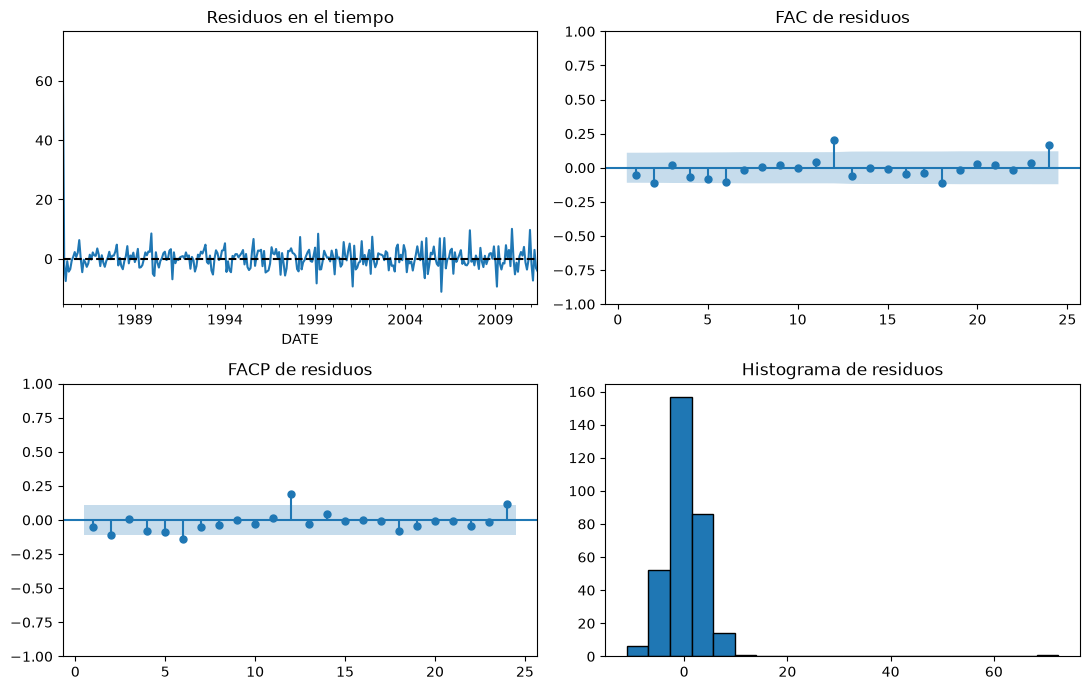

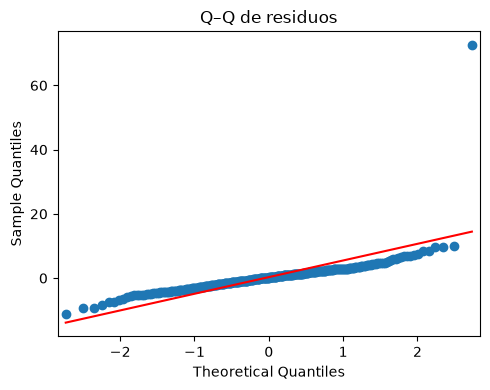

In [12]:
residuales = modelo.resid.dropna()
print('Residuos disponibles:', len(residuales))

# Gráficos de los errores del modelo
fig, axes = plt.subplots(2, 2, figsize=(11, 7))
residuales.plot(ax=axes[0, 0], title='Residuos en el tiempo')
axes[0, 0].axhline(0, color='black', linestyle='--')
plot_acf(residuales, lags=24, zero=False, ax=axes[0, 1], title='FAC de residuos')
plot_pacf(residuales, lags=24, zero=False, method='ywm', ax=axes[1, 0], title='FACP de residuos')
axes[1, 1].hist(residuales, bins=20, edgecolor='black')
axes[1, 1].set_title('Histograma de residuos')
plt.tight_layout(); plt.show()

fig, ax = plt.subplots(figsize=(5, 4))
qqplot(residuales, line='s', ax=ax)
ax.set_title('Q–Q de residuos')
plt.tight_layout(); plt.show()


### 6.2. Gráficos de los residuos


### 6.3. Ljung–Box, ARCH y Jarque–Bera

En las tres pruebas se considera aceptable un p-valor mayor o igual a 0,05: no hay evidencia suficiente para rechazar la hipótesis nula.

- **Ljung–Box**: aceptable si p ≥ 0,05; los residuos no muestran autocorrelación. Si p < 0,05, se prueba otro orden p o q.
- **ARCH**: aceptable si p ≥ 0,05; no se detecta heterocedasticidad condicional. Si p < 0,05, la variabilidad cambia en el tiempo.
- **Jarque–Bera**: aceptable si p ≥ 0,05; los residuos son compatibles con normalidad. Si p < 0,05, no son normales, aunque el modelo puede seguir siendo útil si Ljung–Box es aceptable.

Además, la media de los residuos debe estar próxima a cero y las FAC/FACP de residuos no deben mostrar picos relevantes.


In [13]:
lb = acorr_ljungbox(residuales, lags=[10], return_df=True)
arch = het_arch(residuales, nlags=10, result_object=False)
jb = jarque_bera(residuales)
pruebas = pd.DataFrame({'Prueba':['Ljung–Box','ARCH','Jarque–Bera'], 'Estadístico':[lb['lb_stat'].iloc[0],arch[0],jb[0]], 'p-valor':[lb['lb_pvalue'].iloc[0],arch[1],jb[1]]})
pruebas['Interpretación'] = np.where(pruebas['p-valor'] >= alpha,
                                     'Aceptable: p-valor ≥ 0,05',
                                     'Revisar: p-valor < 0,05')
display(pruebas)
print(f'Media de residuos: {residuales.mean():.4f}')

,Prueba,Estadístico,p-valor
0,Ljung–Box,12.490549,0.253566
1,ARCH,15.647207,0.110187
2,Jarque–Bera,182354.031218,0.000000


Media de residuos: 0.3061


## 7. Fase 4: pronóstico y evaluación

### 7.1. Pronóstico del conjunto de prueba

El modelo queda fijado antes de consultar los errores de prueba. Se pronostica todo el bloque desde el último día de entrenamiento, sin actualizar con valores de `test`. Se compara con una referencia ingenua: repetir el último cierre conocido.

Los intervalos del 95 % dependen de los supuestos del modelo; su cobertura puede ser inadecuada si ARCH o Jarque–Bera rechazan sus hipótesis.


,Real,Pronóstico,Ingenuo,Inferior 95%,Superior 95%
2011-06-01,102.8204,101.799819,90.0698,95.566905,108.032734
2011-07-01,114.7068,108.693820,90.0698,100.147729,117.239910
2011-08-01,113.5958,103.853077,90.0698,93.729826,113.976328
2011-09-01,99.4712,92.131522,90.0698,80.661637,103.601407
2011-10-01,90.3566,85.268595,90.0698,72.425207,98.111983


,Real,Pronóstico,Ingenuo,Inferior 95%,Superior 95%
2017-09-01,98.6154,91.613445,90.0698,40.904457,142.322434
2017-10-01,93.6137,85.492863,90.0698,34.452421,136.533305
2017-11-01,97.3359,90.873501,90.0698,39.457374,142.289628
2017-12-01,114.7212,102.361068,90.0698,50.571470,154.150666
2018-01-01,129.4048,108.450884,90.0698,56.335743,160.566026


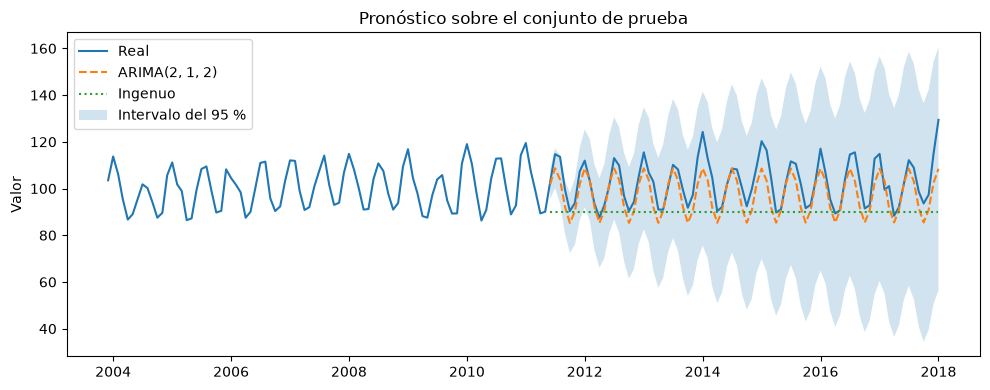

In [14]:
pronostico = modelo.get_forecast(steps=len(test))
intervalo = pronostico.conf_int(alpha=alpha)
prediccion = pronostico.predicted_mean

evaluacion = pd.DataFrame({'Real': test, 'Pronóstico': prediccion,
                           'Ingenuo': train.iloc[-1],
                           'Inferior 95%': intervalo.iloc[:, 0],
                           'Superior 95%': intervalo.iloc[:, 1]})
display(evaluacion.head())
display(evaluacion.tail())

plt.plot(pd.concat([train.tail(90), test]), label='Real')
plt.plot(prediccion, label=nombre, linestyle='--')
plt.plot(test.index, evaluacion['Ingenuo'], label='Ingenuo', linestyle=':')
plt.fill_between(test.index, intervalo.iloc[:, 0], intervalo.iloc[:, 1],
                 alpha=0.2, label='Intervalo del 95 %')
plt.title('Pronóstico sobre el conjunto de prueba')
plt.ylabel('Valor')
plt.legend()
plt.tight_layout()
plt.show()

### 7.1. Errores del pronóstico

MSE, RMSE, MAE y MAPE: cuanto menores, mejor. RMSE y MAE quedan en la escala de la serie, MSE en unidades cuadradas y MAPE en porcentaje. Las métricas del bloque completo se complementan con los primeros 30 periodos, un horizonte más corto.


Todo el conjunto de prueba:


,MSE,RMSE,MAE,MAPE (%)
"ARIMA(2, 1, 2)",49.34,7.02,5.69,5.40
Ingenuo,251.48,15.86,12.78,11.71


Primeros 30 periodos de prueba:


,MSE,RMSE,MAE,MAPE (%)
"ARIMA(2, 1, 2)",26.38,5.14,4.41,4.34
Ingenuo,193.93,13.93,11.32,10.60


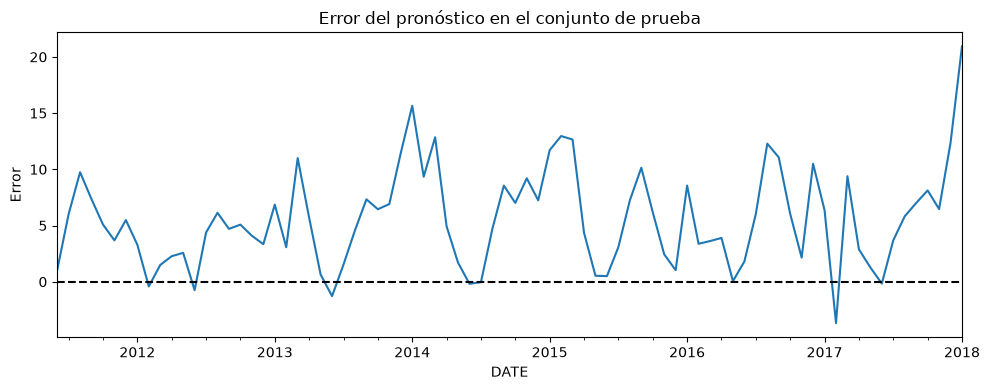

In [15]:
def metricas(real, estimado):
    error = real - estimado
    mse = np.mean(error ** 2)
    return {'MSE': mse, 'RMSE': np.sqrt(mse), 'MAE': np.mean(np.abs(error)),
            'MAPE (%)': np.mean(np.abs(error / real)) * 100}

metricas_test = pd.DataFrame({
    nombre: metricas(test, evaluacion['Pronóstico']),
    'Ingenuo': metricas(test, evaluacion['Ingenuo'])
}).T
print('Todo el conjunto de prueba:')
display(metricas_test.round(2))
h_corto = min(30, len(test))
print(f'Primeros {h_corto} periodos de prueba:')
display(pd.DataFrame({
    nombre: metricas(test.iloc[:h_corto], evaluacion['Pronóstico'].iloc[:h_corto]),
    'Ingenuo': metricas(test.iloc[:h_corto], evaluacion['Ingenuo'].iloc[:h_corto])
}).T.round(2))

# Error de pronóstico: valor observado menos valor pronosticado
error_pronostico = test - evaluacion['Pronóstico']
error_pronostico.plot(title='Error del pronóstico en el conjunto de prueba', ylabel='Error')
plt.axhline(0, color='black', linestyle='--')
plt.tight_layout(); plt.show()


### 7.2. Reajuste y pronóstico futuro

Se conserva el orden elegido y se reestiman los parámetros con toda la serie. El horizonte empieza después de la última fecha descargada; este pronóstico no es una evaluación con datos observados.


,Pronóstico,Inferior 95%,Superior 95%
2018-02-01,126.27,119.68,132.86
2018-03-01,114.15,105.04,123.27
2018-04-01,105.17,94.34,116.01
2018-05-01,108.30,96.06,120.54
2018-06-01,120.41,106.79,134.03
2018-07-01,129.38,114.33,144.44
2018-08-01,126.26,109.83,142.69
2018-09-01,114.17,96.57,131.77
2018-10-01,105.20,86.65,123.75
2018-11-01,108.31,88.91,127.72


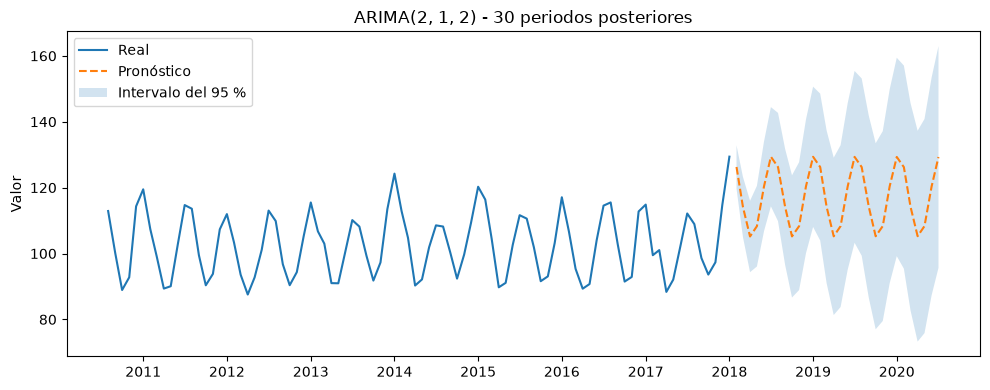

In [16]:
with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    modelo_final = ARIMA(serie, order=orden_elegido, trend=trend, freq=frecuencia).fit(method_kwargs={'maxiter': 100})
if not modelo_final.mle_retvals.get('converged', False):
    raise ValueError('El reajuste final no convergió. Revisar antes de pronosticar.')

horizonte_futuro = 30
futuro = modelo_final.get_forecast(steps=horizonte_futuro)
intervalo_futuro = futuro.conf_int(alpha=alpha)
tabla_futuro = pd.DataFrame({'Pronóstico': futuro.predicted_mean,
                             'Inferior 95%': intervalo_futuro.iloc[:, 0],
                             'Superior 95%': intervalo_futuro.iloc[:, 1]})
display(tabla_futuro.round(2))

plt.plot(serie.tail(90), label='Real')
plt.plot(tabla_futuro['Pronóstico'], label='Pronóstico', linestyle='--')
plt.fill_between(tabla_futuro.index, tabla_futuro['Inferior 95%'],
                 tabla_futuro['Superior 95%'], alpha=0.2, label='Intervalo del 95 %')
plt.title(f'{nombre} - {horizonte_futuro} periodos posteriores')
plt.ylabel('Valor')
plt.legend()
plt.tight_layout()
plt.show()

## 8. Conclusiones

In [17]:
print(f'1. Se analizaron {len(serie)} observaciones de {nombre_serie} con frecuencia {periodo_txt}.')
print(f'2. Se seleccionó d={d}, según la prueba ADF.')
print(f'3. El modelo elegido por AIC fue ARIMA{orden_elegido}.')
print(f'4. RMSE del pronóstico: {metricas_test.loc[nombre, "RMSE"]:.2f}.')
print('5. Las pruebas de residuos se muestran en la tabla anterior.')
print('6. El pronóstico es una estimación; no reproduce exactamente cada variación futura.')

1. Se analizaron 397 observaciones de Producción eléctrica (Kaggle) con frecuencia mensual.
2. Se seleccionó d=1, según la prueba ADF.
3. El modelo elegido por AIC fue ARIMA(2, 1, 2).
4. RMSE del pronóstico: 7.02.
5. Las pruebas de residuos se muestran en la tabla anterior.
6. El pronóstico es una estimación; no reproduce exactamente cada variación futura.
